In [1]:
# ====== Instalação (se precisar de tqdm apenas) ======
!pip -q install tqdm

# ====== Imports ======
import os, io, math, copy, json, random
import numpy as np
import pandas as pd
from tqdm import trange, tqdm

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader


In [2]:
# ====== Defina aqui a URL para o CSV do Heart Attack ======
# Exemplos de schemas comuns: colunas ['age','sex','cp','trestbps','chol','fbs','restecg','thalach','exang','oldpeak','slope','ca','thal','target']
DATA_URL = ""  # cole a URL se tiver; caso contrário deixe vazio e use upload.

if DATA_URL:
    df = pd.read_csv(DATA_URL)
else:
    # ====== Upload manual ======
    from google.colab import files
    up = files.upload()   # faça upload de um CSV com a coluna alvo chamada "target" (0/1)
    fname = list(up.keys())[0]
    df = pd.read_csv(io.BytesIO(up[fname]))

print(df.head())
print(df.shape, df.dtypes)
assert 'target' in df.columns, "A coluna alvo deve chamar-se 'target' (0/1). Renomeie no CSV se necessário."


Saving heart.csv to heart.csv
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  target  
0   0     1       1  
1   0     2       1  
2   0     2       1  
3   0     2       1  
4   0     2       1  
(303, 14) age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object


Pré-processamento (numérico + categórico)

Faz imputação simples,

One-hot para categóricas,

Padronização para numéricas,

## Divide train/val/test.

In [3]:
# Detecta tipos simples (ajuste se desejar forçar categorias específicas)
numeric_cols = [c for c in df.columns if c != 'target' and pd.api.types.is_numeric_dtype(df[c])]
categorical_cols = [c for c in df.columns if c != 'target' and not pd.api.types.is_numeric_dtype(df[c])]

X = df.drop(columns=['target'])
y = df['target'].astype(int).values

numeric_pipe = Pipeline([
    ('imp', SimpleImputer(strategy='median')),
    ('sc', StandardScaler())
])

categorical_pipe = Pipeline([
    ('imp', SimpleImputer(strategy='most_frequent')),
    ('oh', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preproc = ColumnTransformer([
    ('num', numeric_pipe, numeric_cols),
    ('cat', categorical_pipe, categorical_cols)
], remainder='drop')

# split
X_train0, X_test0, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
X_train0, X_val0, y_train, y_val = train_test_split(X_train0, y_train, test_size=0.20, random_state=42, stratify=y_train)

# fit transform
X_train = preproc.fit_transform(X_train0)
X_val   = preproc.transform(X_val0)
X_test  = preproc.transform(X_test0)

print("Shapes:", X_train.shape, X_val.shape, X_test.shape)
input_dim = X_train.shape[1]
n_classes = len(np.unique(y))
assert n_classes == 2, "Este notebook assume classificação binária (target 0/1)."

# tensores
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
Xtr = torch.tensor(X_train, dtype=torch.float32).to(device)
ytr = torch.tensor(y_train, dtype=torch.long).to(device)
Xva = torch.tensor(X_val,   dtype=torch.float32).to(device)
yva = torch.tensor(y_val,   dtype=torch.long).to(device)
Xte = torch.tensor(X_test,  dtype=torch.float32).to(device)
yte = torch.tensor(y_test,  dtype=torch.long).to(device)


Shapes: (193, 13) (49, 13) (61, 13)


# Modelo do artigo (6 → 20 → saída, ReLU)**negrito**

In [4]:
class TinyNet(nn.Module):
    def __init__(self, in_dim, hidden1=6, hidden2=20, out_dim=1):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, hidden1)
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.fc3 = nn.Linear(hidden2, out_dim)
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)  # logits

def make_model():
    model = TinyNet(input_dim, 6, 20, 1).to(device)
    return model

def metrics_from_logits(logits, y_true):
    probs = torch.sigmoid(logits).detach().cpu().numpy().ravel()
    yhat = (probs >= 0.5).astype(int)
    y_true = y_true.detach().cpu().numpy().ravel()
    acc  = accuracy_score(y_true, yhat)
    prec = precision_score(y_true, yhat, zero_division=0)
    rec  = recall_score(y_true, yhat, zero_division=0)
    f1   = f1_score(y_true, yhat, zero_division=0)
    return acc, prec, rec, f1


**ADAM**

In [5]:
def train_adam(epochs=200, batch_size=64, lr=1e-3, wd=0.0, verbose=False):
    model = make_model()
    opt   = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    lossf = nn.BCEWithLogitsLoss()

    ds = TensorDataset(Xtr, ytr.float())
    dl = DataLoader(ds, batch_size=batch_size, shuffle=True)

    hist = {'train_loss':[], 'val_loss':[]}
    for ep in trange(epochs, desc="Adam", leave=False):
        model.train()
        tl = 0.0; n=0
        for xb, yb in dl:
            opt.zero_grad()
            logits = model(xb).squeeze(1)
            loss = lossf(logits, yb)
            loss.backward()
            opt.step()
            tl += loss.item()*xb.size(0); n += xb.size(0)
        tl /= n

        model.eval()
        with torch.no_grad():
            val_logits = model(Xva).squeeze(1)
            vl = lossf(val_logits, yva.float()).item()

        hist['train_loss'].append(tl)
        hist['val_loss'].append(vl)

    # Final metrics
    model.eval()
    with torch.no_grad():
        tr_logits = model(Xtr).squeeze(1)
        va_logits = model(Xva).squeeze(1)
        te_logits = model(Xte).squeeze(1)

    tr_m = metrics_from_logits(tr_logits, ytr)
    va_m = metrics_from_logits(va_logits, yva)
    te_m = metrics_from_logits(te_logits, yte)
    return model, hist, {'train':tr_m, 'val':va_m, 'test':te_m}

adam_model, adam_hist, adam_metrics = train_adam(epochs=300, batch_size=64, lr=1e-3)
print("Adam metrics (acc, prec, rec, f1):", adam_metrics)


Adam metrics (acc, prec, rec, f1): {'train': (0.8756476683937824, 0.8584070796460177, 0.9238095238095239, 0.8899082568807339), 'val': (0.8571428571428571, 0.9166666666666666, 0.8148148148148148, 0.8627450980392157), 'test': (0.7540983606557377, 0.7368421052631579, 0.8484848484848485, 0.7887323943661971)}


GREY WOLF

In [6]:
def get_param_vector(model):
    with torch.no_grad():
        vecs = [p.detach().view(-1).cpu().numpy() for p in model.parameters()]
    return np.concatenate(vecs)

def set_param_vector(model, vec):
    # sobrescreve os pesos do modelo a partir de um vetor 1D
    i = 0
    with torch.no_grad():
        for p in model.parameters():
            num = p.numel()
            chunk = vec[i:i+num]
            p.copy_(torch.tensor(chunk.reshape(p.shape), dtype=p.dtype, device=p.device))
            i += num

def count_params(model):
    return sum(p.numel() for p in model.parameters())


In [7]:
def eval_fitness(model, X, y, l2=0.0):
    lossf = nn.BCEWithLogitsLoss()
    with torch.no_grad():
        logits = model(X).squeeze(1)
        loss = lossf(logits, y.float()).item()
        if l2>0:
            l2p = 0.0
            for p in model.parameters():
                l2p += (p**2).sum().item()
            loss += l2*l2p
    return loss


In [8]:
def train_gwo(pop=50, iters=100, bounds=(-1.0, 1.0), l2=0.0, seed=123):
    rng = np.random.default_rng(seed)
    base_model = make_model()
    dim = count_params(base_model)

    # Inicializa população uniformemente em [low, high]
    low, high = bounds
    wolves = rng.uniform(low, high, size=(pop, dim))

    # inicializa alpha, beta, delta
    def fitness_of(vec):
        set_param_vector(base_model, vec)
        return eval_fitness(base_model, Xtr, ytr, l2=l2)

    fits = np.array([fitness_of(w) for w in wolves])
    order = np.argsort(fits)
    alpha, beta, delta = wolves[order[0]].copy(), wolves[order[1]].copy(), wolves[order[2]].copy()
    alpha_fit, beta_fit, delta_fit = fits[order[0]], fits[order[1]], fits[order[2]]

    hist = {'train_loss':[], 'val_loss':[]}

    for t in trange(iters, desc="GWO", leave=False):
        a = 2 - 2*(t / (iters-1))  # decresce linearmente de 2 -> 0
        for i in range(pop):
            X1 = alpha; X2 = beta; X3 = delta
            r1, r2 = rng.random(dim), rng.random(dim)
            A1 = 2*a*r1 - a
            C1 = 2*r2
            D_alpha = np.abs(C1*X1 - wolves[i])
            X1_new = X1 - A1*D_alpha

            r1, r2 = rng.random(dim), rng.random(dim)
            A2 = 2*a*r1 - a
            C2 = 2*r2
            D_beta = np.abs(C2*X2 - wolves[i])
            X2_new = X2 - A2*D_beta

            r1, r2 = rng.random(dim), rng.random(dim)
            A3 = 2*a*r1 - a
            C3 = 2*r2
            D_delta = np.abs(C3*X3 - wolves[i])
            X3_new = X3 - A3*D_delta

            wolves[i] = (X1_new + X2_new + X3_new) / 3.0
            # clamp nos limites
            np.clip(wolves[i], low, high, out=wolves[i])

        # Avalia população e atualiza hierarquia
        fits = np.array([fitness_of(w) for w in wolves])
        order = np.argsort(fits)
        alpha_new, beta_new, delta_new = wolves[order[0]], wolves[order[1]], wolves[order[2]]
        alpha_fit_new, beta_fit_new, delta_fit_new = fits[order[0]], fits[order[1]], fits[order[2]]

        # mantém os melhores
        if alpha_fit_new <= alpha_fit:
            alpha, alpha_fit = alpha_new.copy(), alpha_fit_new
        if beta_fit_new <= beta_fit:
            beta, beta_fit = beta_new.copy(), beta_fit_new
        if delta_fit_new <= delta_fit:
            delta, delta_fit = delta_new.copy(), delta_fit_new

        # Log da perda train/val do alpha
        set_param_vector(base_model, alpha)
        tr_loss = eval_fitness(base_model, Xtr, ytr, l2=l2)
        va_loss = eval_fitness(base_model, Xva, yva, l2=0.0)
        hist['train_loss'].append(tr_loss)
        hist['val_loss'].append(va_loss)

    # modelo final = alpha
    set_param_vector(base_model, alpha)
    base_model.eval()
    with torch.no_grad():
        tr_logits = base_model(Xtr).squeeze(1)
        va_logits = base_model(Xva).squeeze(1)
        te_logits = base_model(Xte).squeeze(1)
    tr_m = metrics_from_logits(tr_logits, ytr)
    va_m = metrics_from_logits(va_logits, yva)
    te_m = metrics_from_logits(te_logits, yte)
    return base_model, hist, {'train':tr_m, 'val':va_m, 'test':te_m}

gwo_model, gwo_hist, gwo_metrics = train_gwo(pop=50, iters=120, bounds=(-1.0, 1.0), l2=1e-6)
print("GWO metrics (acc, prec, rec, f1):", gwo_metrics)


GWO metrics (acc, prec, rec, f1): {'train': (0.8860103626943006, 0.8608695652173913, 0.9428571428571428, 0.9), 'val': (0.8571428571428571, 0.8846153846153846, 0.8518518518518519, 0.8679245283018868), 'test': (0.819672131147541, 0.7894736842105263, 0.9090909090909091, 0.8450704225352113)}


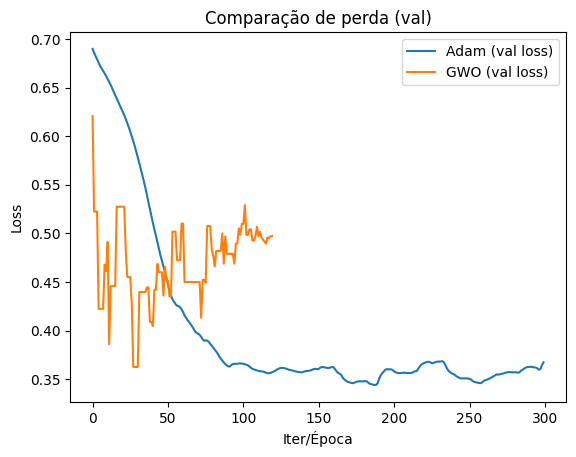

,split,acc,prec,rec,f1,who
0,train,0.875648,0.858407,0.923810,0.889908,Adam
1,val,0.857143,0.916667,0.814815,0.862745,Adam
2,test,0.754098,0.736842,0.848485,0.788732,Adam
3,train,0.886010,0.860870,0.942857,0.900000,GWO
4,val,0.857143,0.884615,0.851852,0.867925,GWO
5,test,0.819672,0.789474,0.909091,0.845070,GWO


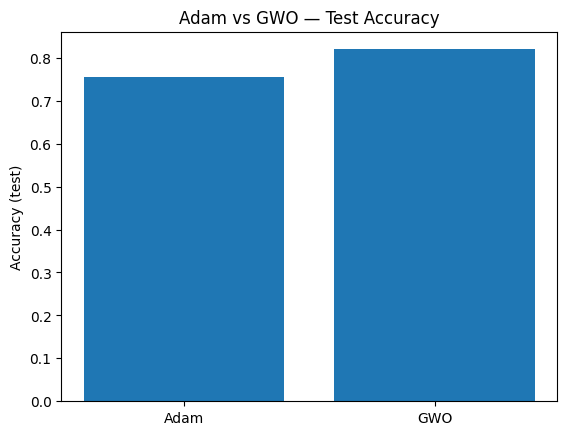

In [9]:
# Curvas de perda
plt.figure()
plt.plot(adam_hist['val_loss'], label='Adam (val loss)')
plt.plot(gwo_hist['val_loss'], label='GWO (val loss)')
plt.xlabel('Iter/Época'); plt.ylabel('Loss'); plt.legend(); plt.title('Comparação de perda (val)')
plt.show()

# Tabela de métricas
def metrics_df(tag, m):
    return pd.DataFrame({
        'split': ['train','val','test'],
        'acc':   [m['train'][0], m['val'][0], m['test'][0]],
        'prec':  [m['train'][1], m['val'][1], m['test'][1]],
        'rec':   [m['train'][2], m['val'][2], m['test'][2]],
        'f1':    [m['train'][3], m['val'][3], m['test'][3]],
        'who':   tag
    })

tab = pd.concat([metrics_df('Adam', adam_metrics), metrics_df('GWO', gwo_metrics)], ignore_index=True)
display(tab)

# Barras comparando acurácia no teste
acc_adam = adam_metrics['test'][0]
acc_gwo  = gwo_metrics['test'][0]
plt.figure()
plt.bar(['Adam','GWO'], [acc_adam, acc_gwo])
plt.ylabel('Accuracy (test)')
plt.title('Adam vs GWO — Test Accuracy')
plt.show()


# Otimizações inspiradas no paper (lado GWO)

In [10]:
def prune_by_magnitude(model, sparsity=0.3):
    # zera os menores |pesos| até atingir a fração 'sparsity'
    with torch.no_grad():
        # empilha todos os pesos (exclui biases? aqui, NÃO — mas você pode escolher)
        all_w = torch.cat([p.view(-1).abs().cpu() for p in model.parameters()])
        kth = torch.quantile(all_w, torch.tensor(sparsity))
        for p in model.parameters():
            mask = p.abs() >= kth.to(p.device)
            p.mul_(mask)

def model_size_bytes(model, dtype=torch.float32):
    # estima memória dos pesos (sem buffers/grad)
    n = sum(p.numel() for p in model.parameters())
    itemsize = torch.tensor([], dtype=dtype).element_size()
    return n * itemsize

def eval_model(model):
    model.eval()
    with torch.no_grad():
        tr_logits = model(Xtr).squeeze(1)
        va_logits = model(Xva).squeeze(1)
        te_logits = model(Xte).squeeze(1)
    return {
        'train': metrics_from_logits(tr_logits, ytr),
        'val':   metrics_from_logits(va_logits, yva),
        'test':  metrics_from_logits(te_logits, yte),
    }

# Copia do GWO e aplica pruning
gwo_pruned = copy.deepcopy(gwo_model)
pre_bytes = model_size_bytes(gwo_pruned, dtype=torch.float32)
prune_by_magnitude(gwo_pruned, sparsity=0.5)  # 50% de pesos a zero (ajuste livre)
post_bytes = model_size_bytes(gwo_pruned, dtype=torch.float32)

gwo_pruned_metrics = eval_model(gwo_pruned)
print("Memória (pesos) float32 antes/depois (bytes):", pre_bytes, post_bytes)
print("GWO-pruned metrics:", gwo_pruned_metrics)


Memória (pesos) float32 antes/depois (bytes): 980 980
GWO-pruned metrics: {'train': (0.8963730569948186, 0.8899082568807339, 0.9238095238095239, 0.9065420560747663), 'val': (0.8775510204081632, 0.92, 0.8518518518518519, 0.8846153846153846), 'test': (0.8032786885245902, 0.7837837837837838, 0.8787878787878788, 0.8285714285714286)}


In [12]:
def to_dtype(model, dtype=torch.float16):
    m2 = copy.deepcopy(model)
    m2 = m2.to(dtype=dtype, device=device)
    return m2

gwo_pruned_f16 = to_dtype(gwo_pruned, dtype=torch.float16)
bytes_f32 = model_size_bytes(gwo_pruned, dtype=torch.float32)
bytes_f16 = model_size_bytes(gwo_pruned_f16, dtype=torch.float16)

# Convert input tensors to float16 as well
Xtr_f16 = Xtr.to(torch.float16)
Xva_f16 = Xva.to(torch.float16)
Xte_f16 = Xte.to(torch.float16)


def eval_model_f16(model):
    model.eval()
    with torch.no_grad():
        tr_logits = model(Xtr_f16).squeeze(1)
        va_logits = model(Xva_f16).squeeze(1)
        te_logits = model(Xte_f16).squeeze(1)
    return {
        'train': metrics_from_logits(tr_logits.float(), ytr), # convert logits back to float for metrics_from_logits
        'val':   metrics_from_logits(va_logits.float(), yva),
        'test':  metrics_from_logits(te_logits.float(), yte),
    }

gwo_pruned_f16_metrics = eval_model_f16(gwo_pruned_f16)
print("Memória (pesos) float32 vs float16 (bytes):", bytes_f32, bytes_f16)
print("GWO-pruned-f16 metrics:", gwo_pruned_f16_metrics)

Memória (pesos) float32 vs float16 (bytes): 980 490
GWO-pruned-f16 metrics: {'train': (0.8963730569948186, 0.8899082568807339, 0.9238095238095239, 0.9065420560747663), 'val': (0.8775510204081632, 0.92, 0.8518518518518519, 0.8846153846153846), 'test': (0.8032786885245902, 0.7837837837837838, 0.8787878787878788, 0.8285714285714286)}


In [13]:
def sweep_gwo(runs=[(30,80),(50,120),(80,150)], l2=1e-6):
    results = []
    for pop, iters in runs:
        m, h, met = train_gwo(pop=pop, iters=iters, bounds=(-1,1), l2=l2, seed=123)
        best_val = min(h['val_loss'])
        results.append({'pop':pop, 'iters':iters, 'best_val_loss':best_val, 'test_acc':met['test'][0]})
    return pd.DataFrame(results)

df_sweep = sweep_gwo()
display(df_sweep)


,pop,iters,best_val_loss,test_acc
0,30,80,0.404394,0.754098
1,50,120,0.362516,0.819672
2,80,150,0.336798,0.786885


,who,split,acc,prec,rec,f1
0,Adam,train,0.875648,0.858407,0.923810,0.889908
1,Adam,val,0.857143,0.916667,0.814815,0.862745
2,Adam,test,0.754098,0.736842,0.848485,0.788732
3,GWO,train,0.886010,0.860870,0.942857,0.900000
4,GWO,val,0.857143,0.884615,0.851852,0.867925
5,GWO,test,0.819672,0.789474,0.909091,0.845070
6,GWO+Pruning,train,0.896373,0.889908,0.923810,0.906542
7,GWO+Pruning,val,0.877551,0.920000,0.851852,0.884615
8,GWO+Pruning,test,0.803279,0.783784,0.878788,0.828571
9,GWO+Pruning+f16,train,0.896373,0.889908,0.923810,0.906542


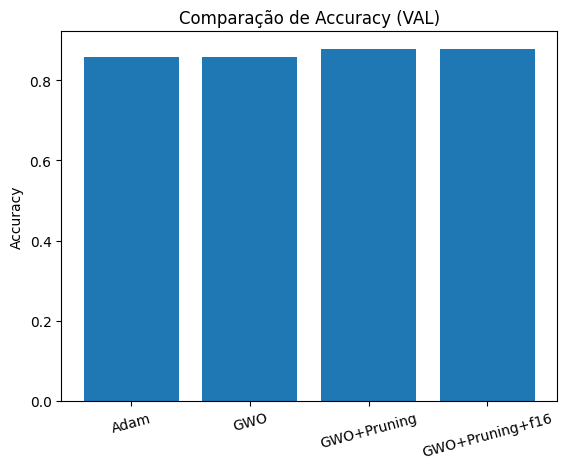

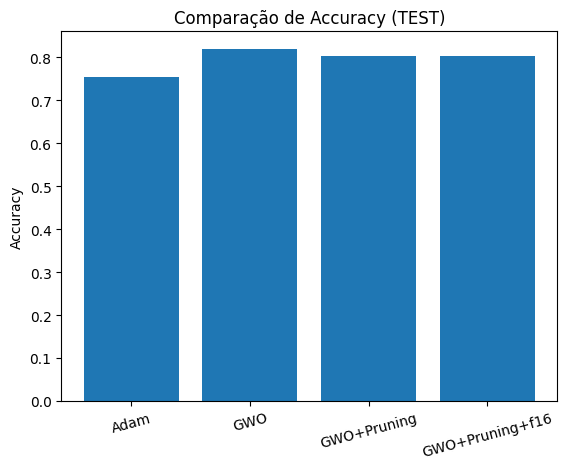

In [14]:
import pandas as pd
import torch
import matplotlib.pyplot as plt

# --- Helpers (reusam funções já definidas no notebook) ---
def ensure_metrics_dict(model, maybe_metrics):
    """Se não veio métrica pronta, calcula agora."""
    if maybe_metrics is not None:
        return maybe_metrics
    model.eval()
    with torch.no_grad():
        tr_logits = model(Xtr).squeeze(1)
        va_logits = model(Xva).squeeze(1)
        te_logits = model(Xte).squeeze(1)
    return {
        'train': metrics_from_logits(tr_logits, ytr),
        'val':   metrics_from_logits(va_logits, yva),
        'test':  metrics_from_logits(te_logits, yte),
    }

def to_rows(tag, m):
    return [
        {'who': tag, 'split':'train', 'acc':m['train'][0], 'prec':m['train'][1], 'rec':m['train'][2], 'f1':m['train'][3]},
        {'who': tag, 'split':'val',   'acc':m['val'][0],   'prec':m['val'][1],   'rec':m['val'][2],   'f1':m['val'][3]},
        {'who': tag, 'split':'test',  'acc':m['test'][0],  'prec':m['test'][1],  'rec':m['test'][2],  'f1':m['test'][3]},
    ]

# --- Garante que todas as métricas existem ---
adam_metrics_ready = ensure_metrics_dict(adam_model, adam_metrics if 'adam_metrics' in globals() else None)
gwo_metrics_ready  = ensure_metrics_dict(gwo_model,  gwo_metrics  if 'gwo_metrics'  in globals() else None)

# Pode ser que você tenha apenas um dos otimizados (com ou sem float16); lidamos com ambos os casos.
gwo_pruned_metrics_ready = None
if 'gwo_pruned' in globals():
    gwo_pruned_metrics_ready = ensure_metrics_dict(gwo_pruned, gwo_pruned_metrics if 'gwo_pruned_metrics' in globals() else None)

gwo_pruned_f16_metrics_ready = None
if 'gwo_pruned_f16' in globals():
    gwo_pruned_f16_metrics_ready = ensure_metrics_dict(gwo_pruned_f16, gwo_pruned_f16_metrics if 'gwo_pruned_f16_metrics' in globals() else None)

# --- Monta tabela final ---
rows = []
rows += to_rows('Adam', adam_metrics_ready)
rows += to_rows('GWO',  gwo_metrics_ready)
if gwo_pruned_metrics_ready:
    rows += to_rows('GWO+Pruning', gwo_pruned_metrics_ready)
if gwo_pruned_f16_metrics_ready:
    rows += to_rows('GWO+Pruning+f16', gwo_pruned_f16_metrics_ready)

comp_df = pd.DataFrame(rows)
display(comp_df)

# --- Gráficos de barras (accuracy) para VAL e TEST ---
for split in ['val','test']:
    subset = comp_df[comp_df['split']==split]
    plt.figure()
    plt.bar(subset['who'], subset['acc'])
    plt.ylabel('Accuracy')
    plt.title(f'Comparação de Accuracy ({split.upper()})')
    plt.xticks(rotation=15)
    plt.show()


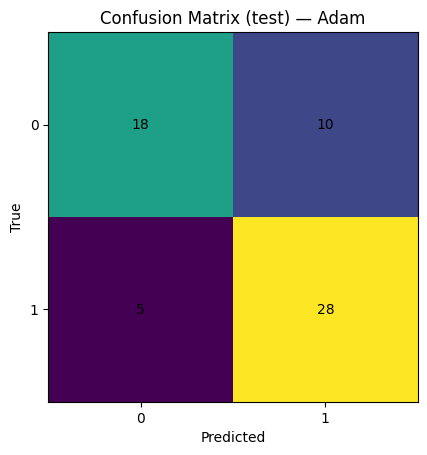

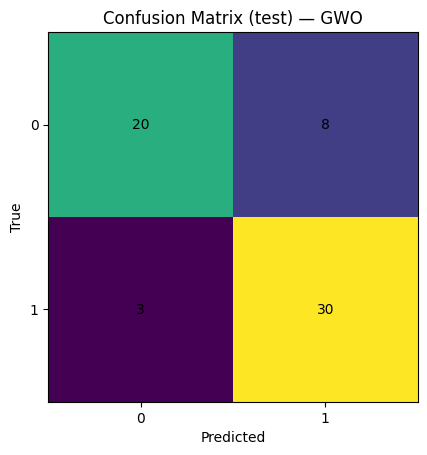

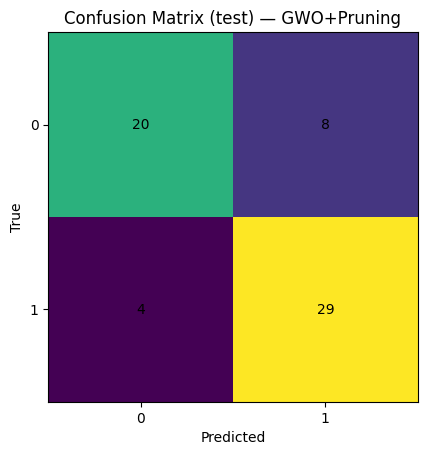

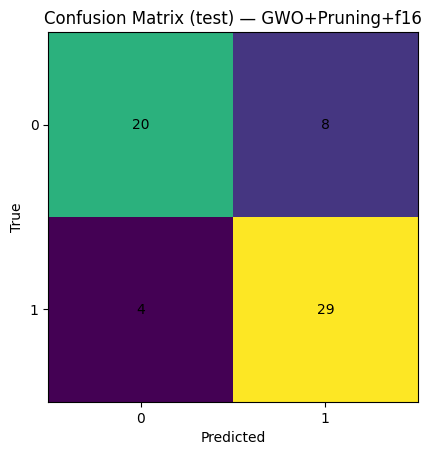

In [16]:
from sklearn.metrics import confusion_matrix

def plot_confmat(model, name='model'):
    model.eval()
    with torch.no_grad():
        # Convert input tensor to the model's dtype if necessary
        input_tensor = Xte.to(model.fc1.weight.dtype)
        logits = model(input_tensor).squeeze(1)
        probs  = torch.sigmoid(logits).cpu().numpy().ravel()
        yhat   = (probs >= 0.5).astype(int)
        ytrue  = yte.cpu().numpy().ravel()

    cm = confusion_matrix(ytrue, yhat, labels=[0,1])
    fig = plt.figure()
    plt.imshow(cm, interpolation='nearest')
    plt.title(f'Confusion Matrix (test) — {name}')
    plt.xticks([0,1], ['0','1'])
    plt.yticks([0,1], ['0','1'])
    for (i,j),v in np.ndenumerate(cm):
        plt.text(j, i, str(v), ha='center', va='center')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

# Gere as matrizes que quiser comparar:
plot_confmat(adam_model, name='Adam')
plot_confmat(gwo_model,  name='GWO')
if 'gwo_pruned' in globals():
    plot_confmat(gwo_pruned, name='GWO+Pruning')
if 'gwo_pruned_f16' in globals():
    plot_confmat(gwo_pruned_f16, name='GWO+Pruning+f16')